<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка-и-предобработка-данных" data-toc-modified-id="Подготовка-и-предобработка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка и предобработка данных</a></span></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span></li><li><span><a href="#Корреляционный-анализ" data-toc-modified-id="Корреляционный-анализ-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Корреляционный анализ</a></span></li><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Подготовка данных</a></span></li><li><span><a href="#Обучение-модели" data-toc-modified-id="Обучение-модели-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Обучение модели</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Выводы</a></span><ul class="toc-item"><li><span><a href="#Улучшение-модели:" data-toc-modified-id="Улучшение-модели:-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Улучшение модели:</a></span></li></ul></li></ul></div>

# Прогнозирование выдачи купонов

## Подготовка и предобработка данных

**Установим необходимые библиотеки.**

In [1]:
!pip install chart_studio -q
!pip install cufflinks -q
!pip install phik -q
!pip install -U scikit-learn -q
!pip install shap -q

**Импортируем библиотеки для работы с данными.**

In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#import plotly
import chart_studio.plotly as py
import cufflinks as cf
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
%matplotlib inline
init_notebook_mode(connected=True)
cf.go_offline()
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import phik
import shap

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

# загружаем класс pipeline
from sklearn.pipeline import Pipeline

# загружаем классы для подготовки данных
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, FunctionTransformer, LabelEncoder
from sklearn.compose import ColumnTransformer

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer

# импортируем класс GridSearchCV
from sklearn.model_selection import GridSearchCV

# загружаем нужные модели
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


**Считаем данные из csv-файла in-vehicle-coupon-recommendation.csv в датафрейм, сохраним в переменную и выведем несколько первых строк. Выведем общую информацию загруженного датафрейма.**

In [3]:
pth = 'in-vehicle-coupon-recommendation.csv'

if os.path.exists(pth):
    data = pd.read_csv(pth, sep=',')
else:
    print('Something is wrong')

display(data)
data.info()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

В данных имеются пропуски, значит может быть получена неполная информация и считываемых данных. Проведем анализ столбцов и заполним пропуски позже.

**Перед началом предобработки данных таблицы, следует скорректировать метаданные, а именно привести названия столбцов к нижнему регистру для повышения читаемости.**

In [4]:
data.columns = data.columns.str.lower()
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalstatus,...,coffeehouse,carryaway,restaurantlessthan20,restaurant20to50,tocoupon_geq5min,tocoupon_geq15min,tocoupon_geq25min,direction_same,direction_opp,y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


**Также проверим датафрейм на наличие явных дубликатов.**

In [5]:
print('Количество явных дубликатов в таблице "ferma_dad":', data.duplicated().sum())

Количество явных дубликатов в таблице "ferma_dad": 74


**Взглянем на эти дубликаты.**

In [6]:
display(data[data.duplicated()].head(10))

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalstatus,...,coffeehouse,carryaway,restaurantlessthan20,restaurant20to50,tocoupon_geq5min,tocoupon_geq15min,tocoupon_geq25min,direction_same,direction_opp,y
4192,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,less1,less1,1,1,1,0,1,1
4236,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,gt8,gt8,4~8,less1,1,1,1,0,1,1
4280,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,26,Single,...,never,4~8,1~3,less1,1,1,1,0,1,1
4324,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,46,Single,...,never,4~8,1~3,1~3,1,1,1,0,1,1
4409,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,21,Single,...,never,less1,1~3,never,1,1,1,0,1,0
4475,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,36,Single,...,never,4~8,1~3,less1,1,1,1,0,1,1
4498,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,26,Single,...,less1,1~3,4~8,never,1,1,1,0,1,0
4586,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,26,Unmarried partner,...,1~3,1~3,1~3,less1,1,1,1,0,1,1
4739,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,below21,Single,...,4~8,NaN,4~8,less1,1,1,1,0,1,1
4761,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,50plus,Single,...,never,less1,4~8,less1,1,1,1,0,1,1


Судя по этим данным, мы имеем обобщенную характеристику по пассажирам. Столбцы, по котороым можно уникализировать данным и однозначно сказать что это дубль нельзя, поэтому дубли будем считать совпадением. По этой же причине не использовался параметр subset.

**Выведем пропуски в данных.**

In [7]:
display(data[data.isna().any(axis=1)])

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalstatus,...,coffeehouse,carryaway,restaurantlessthan20,restaurant20to50,tocoupon_geq5min,tocoupon_geq15min,tocoupon_geq25min,direction_same,direction_opp,y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0


**Присутствуют пропуски в категориальных данных. Рассмортрим их поподробнее.**

In [8]:
def show_column_uniques(df, name):
    print(f'Данные таблицы "{name}":')
    for column in df.select_dtypes(exclude='number').columns.to_list():
        print(column, df[column].unique())
    print('\n')  
    
show_column_uniques(data, "in-vehicle-coupon-recommendation")

Данные таблицы "in-vehicle-coupon-recommendation":
destination ['No Urgent Place' 'Home' 'Work']
passanger ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
weather ['Sunny' 'Rainy' 'Snowy']
time ['2PM' '10AM' '6PM' '7AM' '10PM']
coupon ['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
expiration ['1d' '2h']
gender ['Female' 'Male']
age ['21' '46' '26' '31' '41' '50plus' '36' 'below21']
maritalstatus ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
education ['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']
occupation ['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 'Personal Care & Service'
 'Community & Social S

Требуется заполнить недостающие признаки в категориальных данных. Если удалим их, возможно потеряем важный признак модели, поэтому выделим их в отдельную категорию чтобы сохранить и не повлиять на заполненные признаки.

In [9]:
columns_to_fill = ['car', 'bar', 'coffeehouse', 'carryaway', 'restaurantlessthan20', 'restaurant20to50']
data[columns_to_fill] = data[columns_to_fill].fillna('unknown')
show_column_uniques(data, "in-vehicle-coupon-recommendation")

Данные таблицы "in-vehicle-coupon-recommendation":
destination ['No Urgent Place' 'Home' 'Work']
passanger ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
weather ['Sunny' 'Rainy' 'Snowy']
time ['2PM' '10AM' '6PM' '7AM' '10PM']
coupon ['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
expiration ['1d' '2h']
gender ['Female' 'Male']
age ['21' '46' '26' '31' '41' '50plus' '36' 'below21']
maritalstatus ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
education ['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']
occupation ['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 'Personal Care & Service'
 'Community & Social S

## Исследовательский анализ данных

**В данных присутствуют только категориальные признаки. Рассмотрим их соотношение.**

In [10]:
def show_pie(df):
    for column in df.columns.to_list():
        values_ratio = df[column].value_counts()
        fig = px.pie(labels=values_ratio.index, values=values_ratio.values, names=values_ratio.index)
        fig.update_layout(title_text=f'Распределение данных в колонке {column}')
        fig.show()            

show_pie(data)   

В целом категориальные признаки корректны. Обработаем аномальные и некорректные значения.
Данные в столбце `car` практически отсутствуют, это признак бесполезен, удалим его.

In [11]:
data = data.drop(columns='car')
data.columns.tolist()

['destination',
 'passanger',
 'weather',
 'temperature',
 'time',
 'coupon',
 'expiration',
 'gender',
 'age',
 'maritalstatus',
 'has_children',
 'education',
 'occupation',
 'income',
 'bar',
 'coffeehouse',
 'carryaway',
 'restaurantlessthan20',
 'restaurant20to50',
 'tocoupon_geq5min',
 'tocoupon_geq15min',
 'tocoupon_geq25min',
 'direction_same',
 'direction_opp',
 'y']

Данные в колонке `tocoupon_geq5min` заполнены одним значением. Этот признак тоже беполезен, удалим его. Все заведения находятся на расстоянии более пяти минут езды.

In [12]:
data = data.drop(columns='tocoupon_geq5min')
data.columns.tolist()

['destination',
 'passanger',
 'weather',
 'temperature',
 'time',
 'coupon',
 'expiration',
 'gender',
 'age',
 'maritalstatus',
 'has_children',
 'education',
 'occupation',
 'income',
 'bar',
 'coffeehouse',
 'carryaway',
 'restaurantlessthan20',
 'restaurant20to50',
 'tocoupon_geq15min',
 'tocoupon_geq25min',
 'direction_same',
 'direction_opp',
 'y']

Колонки `direction_same` и `direction_opp` имеют одни и те же данные. Удалим одну колонку, переименуем другую.

In [13]:
data = data.drop(columns='direction_opp')
data = data.rename(columns={'direction_same': 'direction'})
data.columns.tolist()

['destination',
 'passanger',
 'weather',
 'temperature',
 'time',
 'coupon',
 'expiration',
 'gender',
 'age',
 'maritalstatus',
 'has_children',
 'education',
 'occupation',
 'income',
 'bar',
 'coffeehouse',
 'carryaway',
 'restaurantlessthan20',
 'restaurant20to50',
 'tocoupon_geq15min',
 'tocoupon_geq25min',
 'direction',
 'y']

## Корреляционный анализ

**Изучим взаимосвязь между признаками. Построим тепловую карту с помощью библиотеки `phik`.**

interval columns not set, guessing: ['temperature', 'has_children', 'tocoupon_geq15min', 'tocoupon_geq25min', 'direction', 'y']


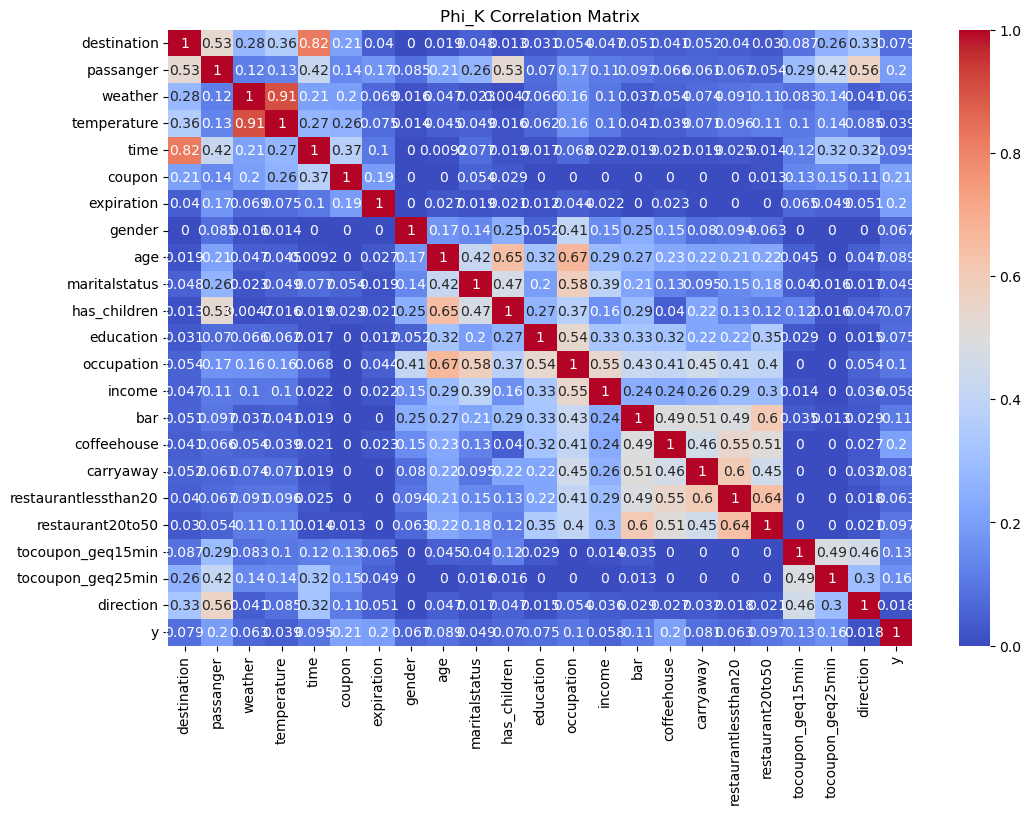

In [14]:
# Вычисление матрицы корреляции с использованием phik
corr_matrix = data.phik_matrix()

# Визуализация матрицы корреляции
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Phi_K Correlation Matrix')
plt.show()

Присутствует мультиколлинеарность признаков между колонками температуры и погоды. Высокая корелляция наблюдается между признаками временем вручения купона и местом назначения. Это логично, ведь пассажиры едут на работы и на отдых примерно в одно и то же время, удалять эти признаки не будет. А вот данные признаков температуры и погоды могут запутать модель, поэтому оставим наиболее информативный - температуру.

In [15]:
data = data.drop(columns='weather')
data.columns.tolist()

['destination',
 'passanger',
 'temperature',
 'time',
 'coupon',
 'expiration',
 'gender',
 'age',
 'maritalstatus',
 'has_children',
 'education',
 'occupation',
 'income',
 'bar',
 'coffeehouse',
 'carryaway',
 'restaurantlessthan20',
 'restaurant20to50',
 'tocoupon_geq15min',
 'tocoupon_geq25min',
 'direction',
 'y']

## Подготовка данных

**Разобьем данные на тренировочные и тестовые и проверим размерность выборок.**

In [16]:
RANDOM_STATE = 110125

X = data.drop('y', axis=1)
y = data['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    stratify=y,
    test_size = 0.2,
    random_state=RANDOM_STATE)

**Создадим и построим пайплайн. Разместим необходимую обработку внутри пайплайна.**

In [17]:
# создаём списки с названиями признаков
ohe_columns = X.columns

# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='not_used')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [     
     ('ohe', ohe_pipe, ohe_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

## Обучение модели

**Обучим модель. С помощью пайплайна найдем лучшую модель. В качестве метрики используем оценку качества ROC AUC.**

In [18]:
# LGBMClassifier
param_grid = [      
     {
        'models': [LGBMClassifier(random_state=RANDOM_STATE)],
        'models__n_estimators': [25, 50],
        'models__learning_rate': [0.01, 0.1]
    }]

In [19]:
grid_search = GridSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', grid_search.best_params_)
print('Метрика лучшей модели на тренировочной выборке:', grid_search.best_score_)

[LightGBM] [Info] Number of positive: 5768, number of negative: 4379
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 188
[LightGBM] [Info] Number of data points in the train set: 10147, number of used features: 94
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.568444 -> initscore=0.275505
[LightGBM] [Info] Start training from score 0.275505
Лучшая модель и её параметры:

 {'models': LGBMClassifier(random_state=110125), 'models__learning_rate': 0.1, 'models__n_estimators': 50}
Метрика лучшей модели на тренировочной выборке: 0.805237160853417


Метрика LGBM модели составляет 0.8

In [28]:
param_grid = [      
     {
        'models': [GradientBoostingClassifier(random_state=RANDOM_STATE)],
        'models__n_estimators': [50, 100, 150, 200],
        'models__learning_rate': [0.01, 0.1, 0.3]
    }]

In [29]:
grid_search = GridSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', grid_search.best_params_)
print('Метрика лучшей модели на тренировочной выборке:', grid_search.best_score_)

Лучшая модель и её параметры:

 {'models': GradientBoostingClassifier(random_state=110125), 'models__learning_rate': 0.3, 'models__n_estimators': 200}
Метрика лучшей модели на тренировочной выборке: 0.8087245723918517


Метрика градиентного бустинга модели составляет 0.8

In [26]:
# CatBoostClassifier
param_grid = [      
     {
         'models': [CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)],
         'models__iterations': [50, 100, 150, 200, 250],
         'models__learning_rate': [0.1, 0.3, 0.4],
         'models__l2_leaf_reg': [3, 9, 12, 15]
     }]

In [27]:
grid_search = GridSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', grid_search.best_params_)
print('Метрика лучшей модели на тренировочной выборке:', grid_search.best_score_)

Лучшая модель и её параметры:

 {'models': <catboost.core.CatBoostClassifier object at 0x000001AA1BB52CD0>, 'models__iterations': 250, 'models__l2_leaf_reg': 9, 'models__learning_rate': 0.3}
Метрика лучшей модели на тренировочной выборке: 0.8244520665148773


Метрика CatBoostClassifier  модели составляет 0.82

**Проверим лучшую модель на тестовых данных.**

In [30]:
# Получение предсказаний вероятностей на тестовых данных
y_pred_proba = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

# Расчет метрики roc_auc на тестовых данных
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('Метрика ROC AUC на тестовых данных:', roc_auc)

Метрика ROC AUC на тестовых данных: 0.8070912418698029


На тестовых данных метрика составила почти 81%.

**Взглянем на график кривой обучения модели.**

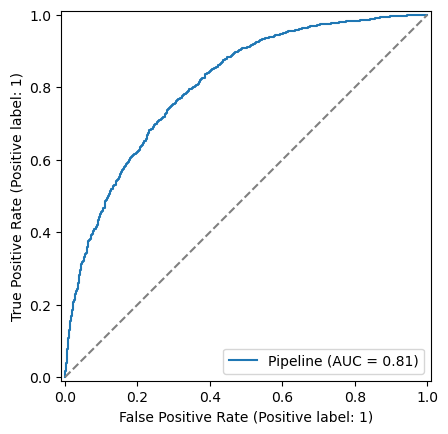

In [34]:
RocCurveDisplay.from_estimator(grid_search.best_estimator_, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.show()

**Построим график важности признаков с помощью библиотеки `shap`.**

  0%|          | 0/20 [00:00<?, ?it/s]

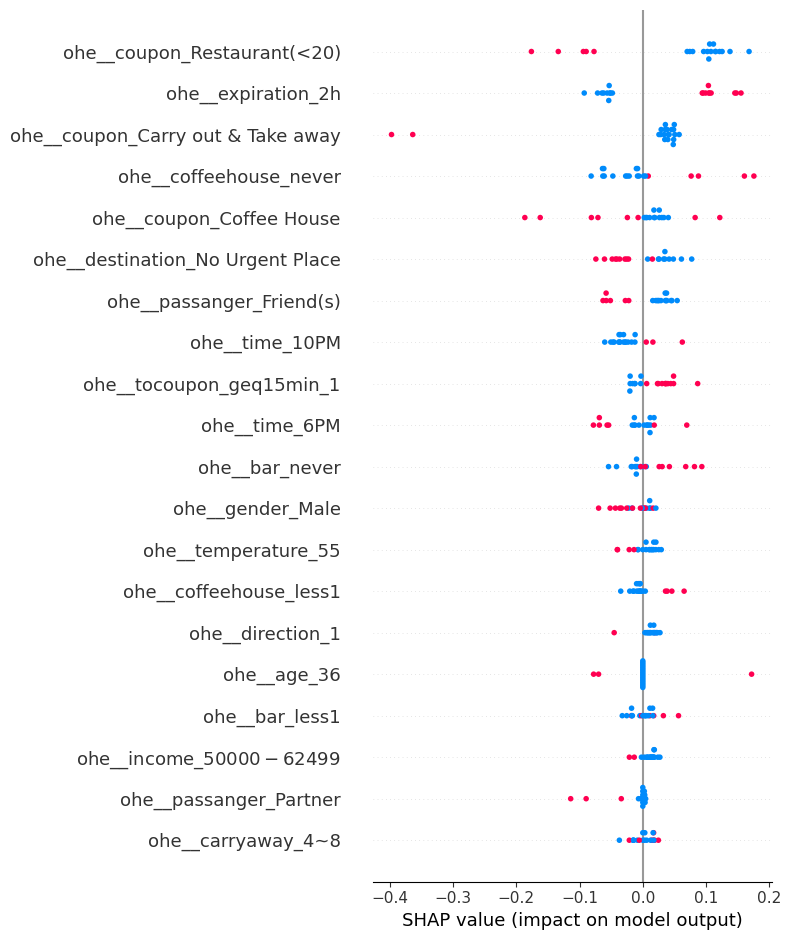

In [32]:
shap.initjs()

best_model = grid_search.best_estimator_

x_Train = pd.DataFrame(
    pipe_final.named_steps['preprocessor'].fit_transform(X_train),
    columns=pipe_final.named_steps['preprocessor'].get_feature_names_out()
)

x_Test = pd.DataFrame(
    pipe_final.named_steps['preprocessor'].transform(X_test),
    columns=pipe_final.named_steps['preprocessor'].get_feature_names_out()
)

cb_model = CatBoostClassifier (iterations=250, l2_leaf_reg=9, learning_rate=0.3, random_state=RANDOM_STATE, verbose=0)
cb_model.fit(x_Train, y_train)

explainer = shap.KernelExplainer(cb_model.predict_proba, x_Train[:20])

shap_values = explainer.shap_values(x_Test[:20])[:,:,0]

shap.summary_plot(shap_values, x_Test[:20], color_bar=False)

**Наибольшее влияние оказывали признаки типа купона и срок его истечения.**

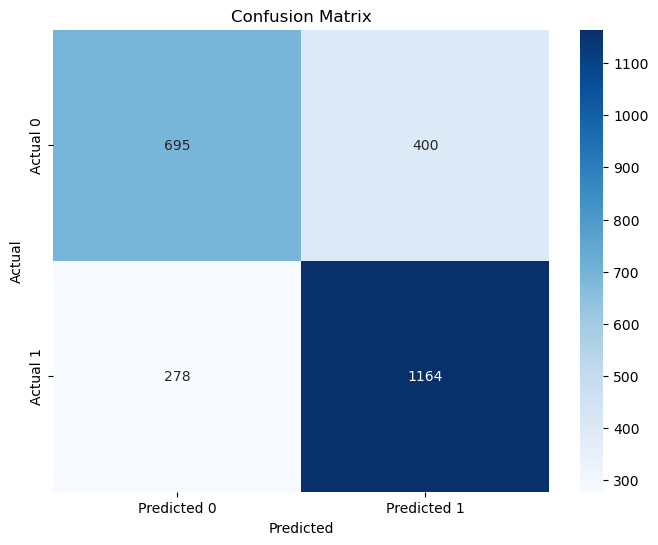

In [33]:
# Предсказания на тестовом наборе
y_pred = grid_search.best_estimator_.predict(X_test)

# Вычисление матрицы ошибок
cm = confusion_matrix(y_test, y_pred)

# Отображение матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Модель показывает неплохие значения на тестовом наборе данных. Это подтверждается высоким уровнем полноты (recall) и точности (precision), что снижает количество ложноположительных и ложноотрицательных значений в матрице ошибок.**

**Кроме того, значение AUC составляет 0,82, а форма кривой находится выше пунктирной линии. Это указывает на то, что данная модель является хорошим предиктором.**

## Выводы

Разработана модель CatBoostClassifier, которая показывает наилучший результат. На тренировочных данных метрика roc-auc составляет 82%, на тестовых 80%. 
### Улучшение модели:

- Мы можем попробовать изменить настройки модели, чтобы лучше распознавать пассажиров, которые выберут купон.